In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the capex sheet
df_capex = pd.read_excel("toy_results.xlsx", sheet_name="capex")

print(df_capex.head())

    technology                         item  investment
0  aquathermal             Water Collectors     26250.0
1  aquathermal  Water Pipes, fittings, etc.     12750.0
2  aquathermal                    E-Cabling      3750.0
3  aquathermal               Source-HP Pump    393925.0
4  aquathermal                   Pump House     25000.0


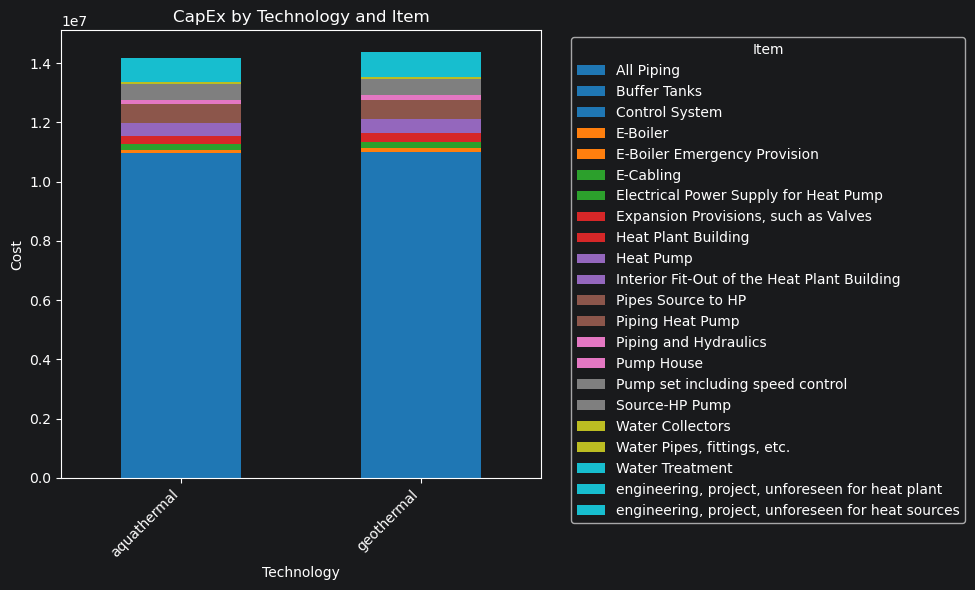

In [4]:
# Pivot: x-axis = technology, stacked segments = item, values = cost
pivot = df_capex.pivot_table(index="technology", columns="item", values="investment", aggfunc="sum")

# Plot stacked bar chart
ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab10"
)

ax.set_title("CapEx by Technology and Item")
ax.set_xlabel("Technology")
ax.set_ylabel("Cost")
ax.legend(title="Item", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
# Load the capex sheet
df_toc = pd.read_excel("toy_results.xlsx", sheet_name="toc")

print(df_toc.head())

                      id   technology     toc   location
0    aquathermal_Enspijk  aquathermal  104000    Enspijk
1     geothermal_Enspijk   geothermal  107000    Enspijk
2            gas_Enspijk          gas   79000    Enspijk
3  aquathermal_Hilversum  aquathermal  100000  Hilversum
4   geothermal_Hilversum   geothermal  156000  Hilversum


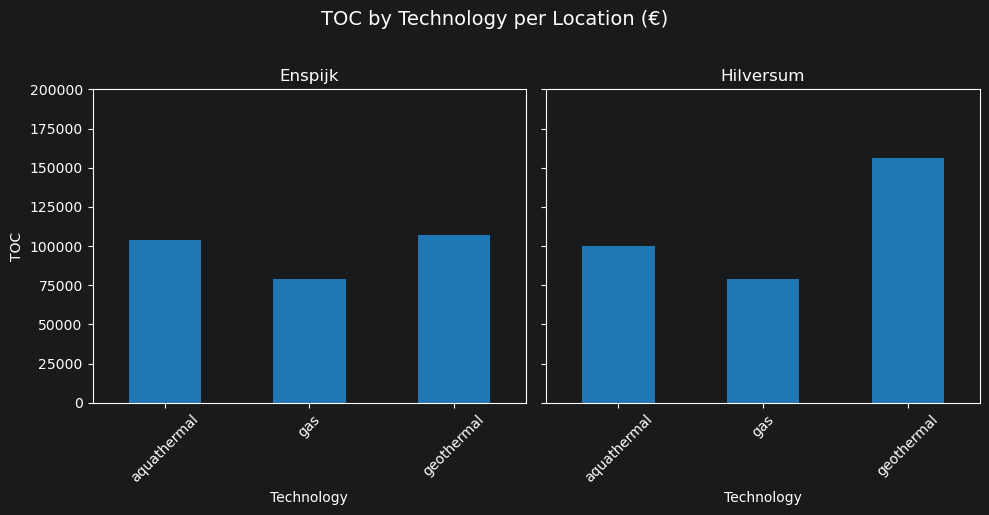

In [6]:
locations = df_toc["location"].unique()
n = len(locations)

fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=True)

if n == 1:
    axes = [axes]

for ax, loc in zip(axes, locations):
    subset = df_toc[df_toc["location"] == loc]
    pivot = subset.pivot_table(index="technology", values="toc", aggfunc="sum")

    pivot.plot(
        kind="bar",
        ax=ax,
        colormap="tab10",
        legend=False
    )

    ax.set_title(loc)
    ax.set_xlabel("Technology")
    ax.set_ylim(0, 200000)
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("TOC")
fig.suptitle("TOC by Technology per Location (\u20ac)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
## chart above is relevant to sensitivity analysis

In [8]:
## include TCO and tariff per tech side by side, per tech.

In [9]:
## box plot, tcos for different sensitivity scenarios, columns are sensitivity techs, highlight as baseline

In [10]:
## dupe for tariff

In [14]:
## toy array of sensitivity results as percentage

# import pandas as pd
# import numpy as np
#
# np.random.seed(42)
#
# technologies = [f"Tech{i}" for i in range(1, 6)]
# n_params = 10
#
# rows = {}
#
# # Baseline row with all zeros
# rows["Baseline"] = np.zeros(5)
#
# for p in range(1, n_params + 1):
#     rows[f"P{p}U"] = np.random.uniform(0, 1, 5)
#     rows[f"P{p}L"] = np.random.uniform(-1, 0, 5)
#
# df_params = pd.DataFrame(rows, index=technologies).T
#
# print(df_params)

             Tech1     Tech2     Tech3     Tech4     Tech5
Baseline  0.000000  0.000000  0.000000  0.000000  0.000000
P1U       0.374540  0.950714  0.731994  0.598658  0.156019
P1L      -0.844005 -0.941916 -0.133824 -0.398885 -0.291927
P2U       0.020584  0.969910  0.832443  0.212339  0.181825
P2L      -0.816595 -0.695758 -0.475244 -0.568055 -0.708771
P3U       0.611853  0.139494  0.292145  0.366362  0.456070
P3L      -0.214824 -0.800326 -0.485766 -0.407585 -0.953550
P4U       0.607545  0.170524  0.065052  0.948886  0.965632
P4L      -0.191603 -0.695386 -0.902328 -0.315767 -0.559848
P5U       0.122038  0.495177  0.034389  0.909320  0.258780
P5L      -0.337478 -0.688289 -0.479932 -0.453290 -0.815146
P6U       0.969585  0.775133  0.939499  0.894827  0.597900
P6L      -0.078126 -0.911507 -0.804017 -0.954773 -0.674670
P7U       0.388677  0.271349  0.828738  0.356753  0.280935
P7L      -0.457304 -0.859076 -0.197803 -0.925449 -0.013113
P8U       0.772245  0.198716  0.005522  0.815461  0.7068

In [37]:
import pandas as pd
import numpy as np

np.random.seed(42)

technologies = [f"Tech{i}" for i in range(1, 6)]
technologies = ["AWHP Individual", "AWHP Collective", "Geothermal", "Aquathermal", "Natural Gas"]
n_params = 10

rows = {}

# Baseline row with all 40s
rows["Baseline"] = np.random.uniform(0, 80, 5)

for p in range(1, n_params + 1):
    rows[f"P{p}U"] = np.random.uniform(40, 80, 5)
    rows[f"P{p}L"] = np.random.uniform(0, 40, 5)

df_params = pd.DataFrame(rows, index=technologies).T

print(df_params)

          AWHP Individual  AWHP Collective  Geothermal  Aquathermal  \
Baseline        29.963210        76.057145   58.559515    47.892679   
P1U             46.239781        42.323344   74.647046    64.044600   
P1L              0.823380        38.796394   33.297706     8.493564   
P2U             47.336180        52.169690   60.990257    57.277801   
P2L             24.474116         5.579754   11.685786    14.654474   
P3U             71.407038        47.986951   60.569378    63.696583   
P3L             24.301794         6.820965    2.602064    37.955421   
P4U             72.335894        52.184551   43.906885    67.369321   
P4L              4.881529        19.807076    1.375541    36.372816   
P5U             66.500891        52.468443   60.802721    61.868411   
P5L             38.783385        31.005313   37.579958    35.793094   
P6U             76.874969        43.539700   47.839314    41.809092   
P6L             15.547092        10.853961   33.149500    14.270133   
P7U   

/var/folders/_q/_8j7xmxj1knfd24nmfn58vf80000gn/T/ipykernel_65008/1188608903.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


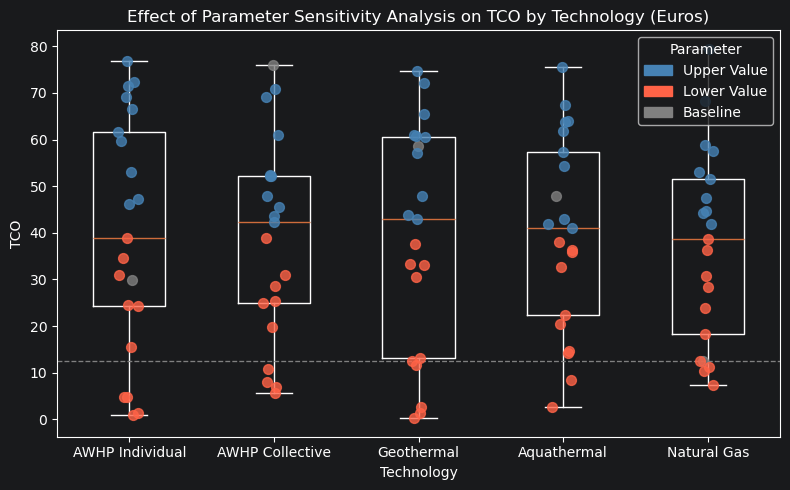

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

color_map = {}
for row in df_params.index:
    if row == "Baseline":
        color_map[row] = "gray"
    elif row.endswith("U"):
        color_map[row] = "steelblue"
    elif row.endswith("L"):
        color_map[row] = "tomato"

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    [df_params[col].values for col in df_params.columns],
    labels=df_params.columns,
    showfliers=False
)

np.random.seed(42)
for i, col in enumerate(df_params.columns, start=1):
    for row in df_params.index:
        y = df_params.loc[row, col]
        x = np.random.normal(i, 0.04)
        ax.scatter(x, y, color=color_map[row], alpha=0.8, zorder=3, s=50)

## baseline for natural gas as benchmark
ax.axhline(df_params.loc["Baseline", "Natural Gas"], color="gray", linestyle="--", linewidth=0.95)

ax.set_title("Effect of Parameter Sensitivity Analysis on TCO by Technology (Euros)")
ax.set_xlabel("Technology")
ax.set_ylabel("TCO")
# ax.axhline(40, color="gray", linestyle="--", linewidth=0.8)  # updated to baseline=40

legend_handles = [
    mpatches.Patch(color="steelblue", label="Upper Value"),
    mpatches.Patch(color="tomato", label="Lower Value"),
    mpatches.Patch(color="gray", label="Baseline"),
]
ax.legend(handles=legend_handles, title="Parameter")

plt.tight_layout()
plt.show()